Supermarket Sales Prediction Using Machine Learning


**Introduction**
This project analyzes supermarket transaction data and develops machine learning models to predict total sales per transaction. The analysis aims to identify factors influencing sales, compare different predictive models, and provide insights that can support inventory management, staffing, pricing, and business decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('SuperMarket Analysis.csv')

# Display the first 5 rows
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [2]:
# Check the dataset size
print("Dataset shape:", df.shape)

# Check column names
print("\nColumn names:")
print(df.columns.tolist())

# Check data types
print("\nData types:")
print(df.dtypes)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (1000, 17)

Column names:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']

Data types:
Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

Missing values:
Invoice ID                 0
Branch                     0
City                       0
Customer type           

**Data Cleaning**

In [3]:
# Make a copy of the dataset
data = df.copy()

# Convert Date to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Convert Time to datetime without specifying an exact format
data['Time'] = pd.to_datetime(data['Time'], errors='coerce')

# Check the updated data types
print(data.dtypes)

Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Sales                             float64
Date                       datetime64[ns]
Time                       datetime64[ns]
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object


/tmp/ipykernel_1289/1780288653.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Time'] = pd.to_datetime(data['Time'], errors='coerce')


In [4]:
# Convert Date to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Convert Time correctly
data['Time'] = pd.to_datetime(
    data['Time'],
    format='%I:%M:%S %p'
)

# Check the data types
print(data.dtypes)

Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Sales                             float64
Date                       datetime64[ns]
Time                       datetime64[ns]
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object


In [5]:
# Date is already correctly formatted
data['Date'] = pd.to_datetime(data['Date'])

# Time is already a datetime column, so extract the hour directly
data['Hour'] = data['Time'].dt.hour

# Create date-based features
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['Day_of_Week'] = data['Date'].dt.day_name()

# Display the new features
data[['Date', 'Time', 'Month', 'Day', 'Day_of_Week', 'Hour']].head()

,Date,Time,Month,Day,Day_of_Week,Hour
0,2019-01-05,2026-09-18 13:08:00,1,5,Saturday,13
1,2019-03-08,2026-09-18 10:29:00,3,8,Friday,10
2,2019-03-03,2026-09-18 13:23:00,3,3,Sunday,13
3,2019-01-27,2026-09-18 20:33:00,1,27,Sunday,20
4,2019-02-08,2026-09-18 10:37:00,2,8,Friday,10


**Create useful time features**

In [6]:
# Extract useful information from Date
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['Day_of_Week'] = data['Date'].dt.day_name()

# Extract hour from Time
data['Hour'] = data['Time'].dt.hour

# Display the new features
data[['Date', 'Time', 'Month', 'Day', 'Day_of_Week', 'Hour']].head()

,Date,Time,Month,Day,Day_of_Week,Hour
0,2019-01-05,2026-09-18 13:08:00,1,5,Saturday,13
1,2019-03-08,2026-09-18 10:29:00,3,8,Friday,10
2,2019-03-03,2026-09-18 13:23:00,3,3,Sunday,13
3,2019-01-27,2026-09-18 20:33:00,1,27,Sunday,20
4,2019-02-08,2026-09-18 10:37:00,2,8,Friday,10


In [7]:
print("Missing Time values:", data['Time'].isnull().sum())

Missing Time values: 0


**Create ML dataset**

In [8]:
# Create a copy for machine learning
ml_data = data.copy()

# Remove columns that should not be predictors
ml_data = ml_data.drop(columns=[
    'Invoice ID',
    'Sales',
    'Tax 5%',
    'cogs',
    'gross income',
    'gross margin percentage',
    'Date',
    'Time'
])

# Define features and target
X = ml_data
y = data['Sales']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Sales")

Features:
['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Payment', 'Rating', 'Hour', 'Year', 'Month', 'Day', 'Day_of_Week']

Target:
Sales


**Basic statistical analysis**

In [9]:
# Basic statistics for numerical variables
data.describe()

,Unit price,Quantity,Tax 5%,Sales,Date,Time,cogs,gross margin percentage,gross income,Rating,Hour,Year,Month,Day
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,1000.00000,1.000000e+03,1000.000000,1000.00000,1000.000000,1000.0,1000.000000,1000.000000
mean,55.672130,5.510000,15.379369,322.966749,2019-02-14 00:05:45.600000,2026-09-18 15:24:41.880000,307.58738,4.761905e+00,15.379369,6.97270,14.910000,2019.0,1.993000,15.256000
min,10.080000,1.000000,0.508500,10.678500,2019-01-01 00:00:00,2026-09-18 10:00:00,10.17000,4.761905e+00,0.508500,4.00000,10.000000,2019.0,1.000000,1.000000
25%,32.875000,3.000000,5.924875,124.422375,2019-01-24 00:00:00,2026-09-18 12:43:00,118.49750,4.761905e+00,5.924875,5.50000,12.000000,2019.0,1.000000,8.000000
50%,55.230000,5.000000,12.088000,253.848000,2019-02-13 00:00:00,2026-09-18 15:19:00,241.76000,4.761905e+00,12.088000,7.00000,15.000000,2019.0,2.000000,15.000000
75%,77.935000,8.000000,22.445250,471.350250,2019-03-08 00:00:00,2026-09-18 18:15:00,448.90500,4.761905e+00,22.445250,8.50000,18.000000,2019.0,3.000000,23.000000
max,99.960000,10.000000,49.650000,1042.650000,2019-03-30 00:00:00,2026-09-18 20:59:00,993.00000,4.761905e+00,49.650000,10.00000,20.000000,2019.0,3.000000,31.000000
std,26.494628,2.923431,11.708825,245.885335,NaN,NaN,234.17651,6.131498e-14,11.708825,1.71858,3.186857,0.0,0.835254,8.693563


In [10]:
# Sales statistics
print("Total Sales:", data['Sales'].sum())
print("Average Sales per Transaction:", data['Sales'].mean())
print("Highest Transaction:", data['Sales'].max())
print("Lowest Transaction:", data['Sales'].min())

Total Sales: 322966.749
Average Sales per Transaction: 322.966749
Highest Transaction: 1042.65
Lowest Transaction: 10.6785


**Sales by Product Line**

In [11]:
# Calculate total sales by product line
product_sales = data.groupby('Product line')['Sales'].sum().sort_values(ascending=False)

print(product_sales)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


**First important visualization**

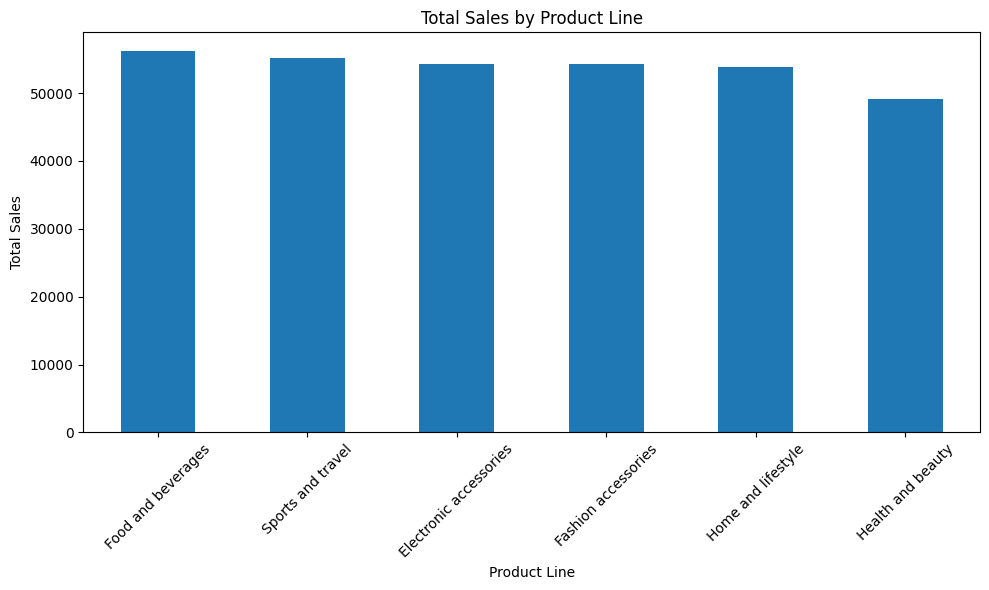

In [12]:
# Visualize sales by product line
plt.figure(figsize=(10, 6))

product_sales.plot(kind='bar')

plt.title('Total Sales by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Sales by Branch**

In [13]:
# Calculate total sales by branch
branch_sales = data.groupby('Branch')['Sales'].sum().sort_values(ascending=False)

print(branch_sales)

Branch
Giza     110568.7065
Alex     106200.3705
Cairo    106197.6720
Name: Sales, dtype: float64


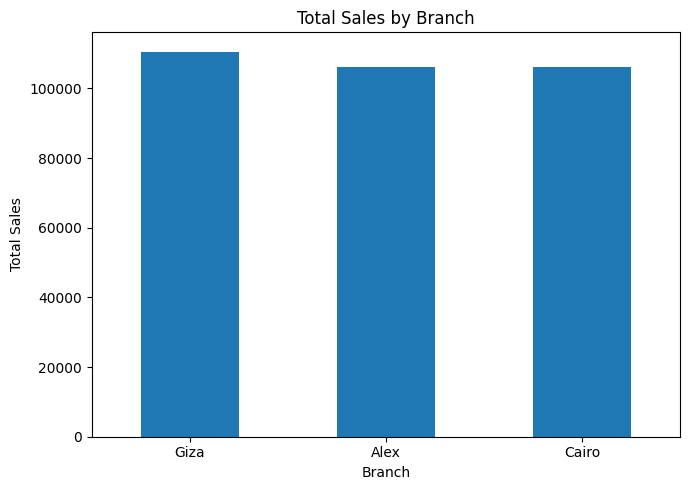

In [14]:
plt.figure(figsize=(7, 5))

branch_sales.plot(kind='bar')

plt.title('Total Sales by Branch')
plt.xlabel('Branch')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Sales by Customer Type**

In [15]:
customer_sales = data.groupby('Customer type')['Sales'].sum().sort_values(ascending=False)

print(customer_sales)

Customer type
Member    189694.764
Normal    133271.985
Name: Sales, dtype: float64


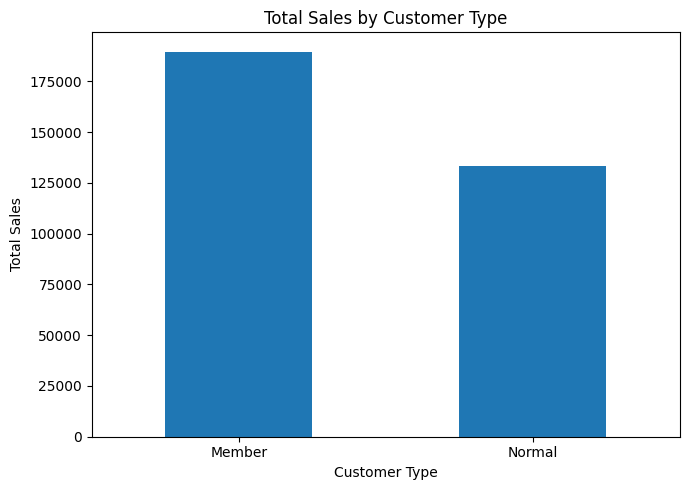

In [16]:
plt.figure(figsize=(7, 5))

customer_sales.plot(kind='bar')

plt.title('Total Sales by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Gender and Payment Analysis**


In [17]:
# Sales by Gender
gender_sales = data.groupby('Gender')['Sales'].sum().sort_values(ascending=False)

print(gender_sales)

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64


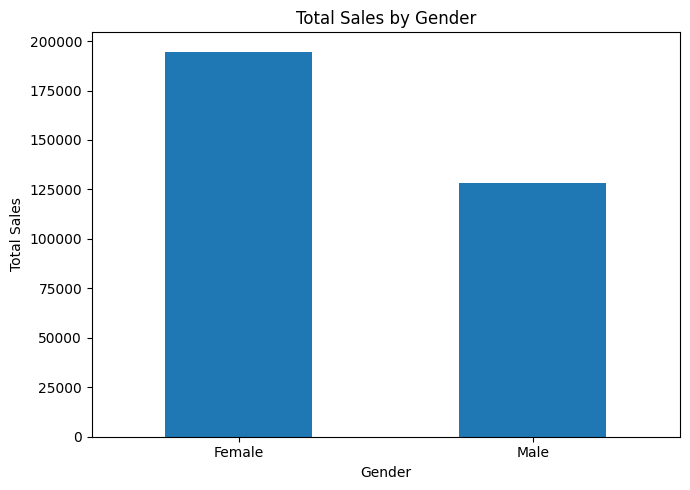

In [18]:
plt.figure(figsize=(7, 5))

gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Payment method**


In [19]:
# Sales by Payment Method
payment_sales = data.groupby('Payment')['Sales'].sum().sort_values(ascending=False)

print(payment_sales)

Payment
Cash           112206.570
Ewallet        109993.107
Credit card    100767.072
Name: Sales, dtype: float64


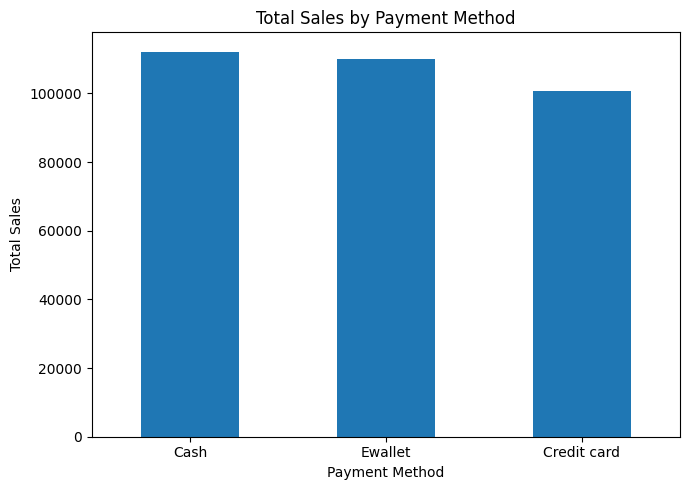

In [20]:
plt.figure(figsize=(7, 5))

payment_sales.plot(kind='bar')

plt.title('Total Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Quantity and Sales**


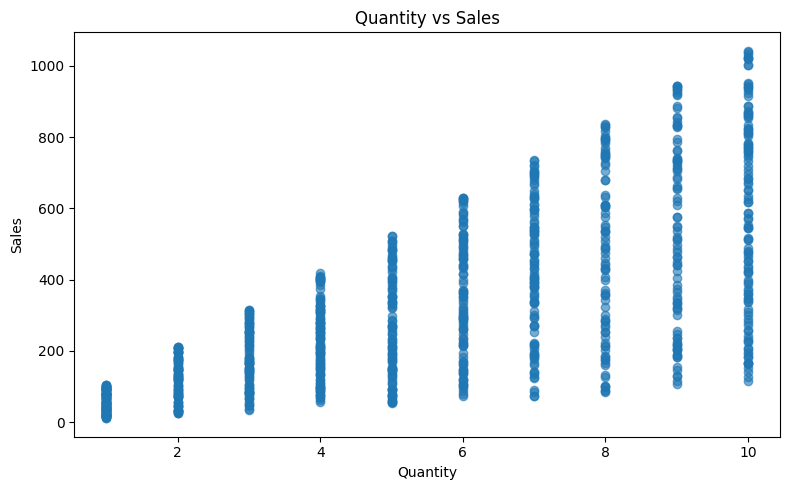

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(data['Quantity'], data['Sales'], alpha=0.6)

plt.title('Quantity vs Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

**Correlation Analysis**


In [22]:
# Select numerical columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Calculate correlations
correlation = numeric_data.corr()

# Display correlation with Sales
sales_correlation = correlation['Sales'].sort_values(ascending=False)

print(sales_correlation)

Sales                      1.000000
gross income               1.000000
Tax 5%                     1.000000
cogs                       1.000000
Quantity                   0.705510
Unit price                 0.633962
Rating                    -0.036442
gross margin percentage         NaN
Name: Sales, dtype: float64


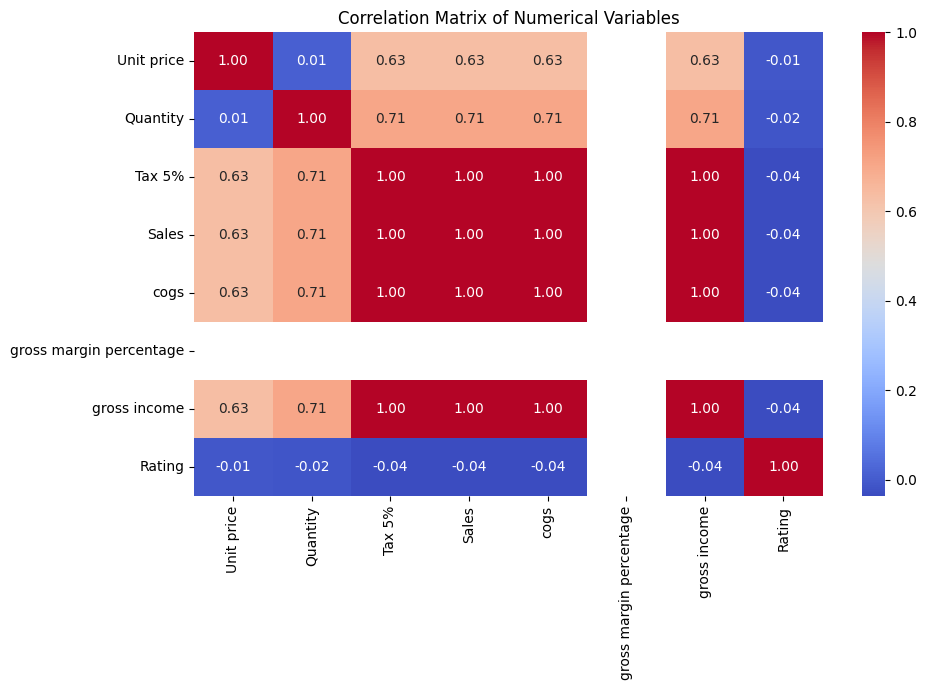

In [23]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

**Separate categorical and numerical**



In [24]:
# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment', 'Day_of_Week']

Numerical features:
['Unit price', 'Quantity', 'Rating']


**Split the data**


In [25]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 14)
Testing data: (200, 14)


**Preprocess the data**

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create the preprocessing step
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numerical', 'passthrough', numerical_features)
    ]
)

print("Preprocessing setup completed successfully.")

Preprocessing setup completed successfully.


**Create the models**

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Linear Regression
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Decision Tree
decision_tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

# Random Forest
random_forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

print("All three models have been created.")

All three models have been created.


**Train the three models**

In [28]:
# Train the Linear Regression model
linear_model.fit(X_train, y_train)

# Train the Decision Tree model
decision_tree_model.fit(X_train, y_train)

# Train the Random Forest model
random_forest_model.fit(X_train, y_train)

print("All three models have been trained successfully.")

All three models have been trained successfully.


**Make predictions**

In [29]:
# Make predictions on the test data
linear_predictions = linear_model.predict(X_test)
tree_predictions = decision_tree_model.predict(X_test)
forest_predictions = random_forest_model.predict(X_test)

print("Predictions completed successfully.")

Predictions completed successfully.


**Evaluate the models**

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
models = {
    'Linear Regression': linear_predictions,
    'Decision Tree': tree_predictions,
    'Random Forest': forest_predictions
}

results = []

for model_name, predictions in models.items():
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R² Score': r2
    })

# Create a results table
results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,59.776846,80.103455,0.901373
1,Decision Tree,9.174322,14.263339,0.996873
2,Random Forest,6.672626,10.127923,0.998423


**Model Performance Interpretation**

The three machine learning models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. The Random Forest model performed best, with an MAE of 6.67, an RMSE of 10.13, and an R² score of 0.9984. This indicates that the Random Forest model provides the most accurate sales predictions among the three models tested. The Decision Tree also performed well, while Linear Regression produced larger prediction errors. Therefore, Random Forest was selected as the final model for predicting supermarket sales.


**Create a model comparison chart**

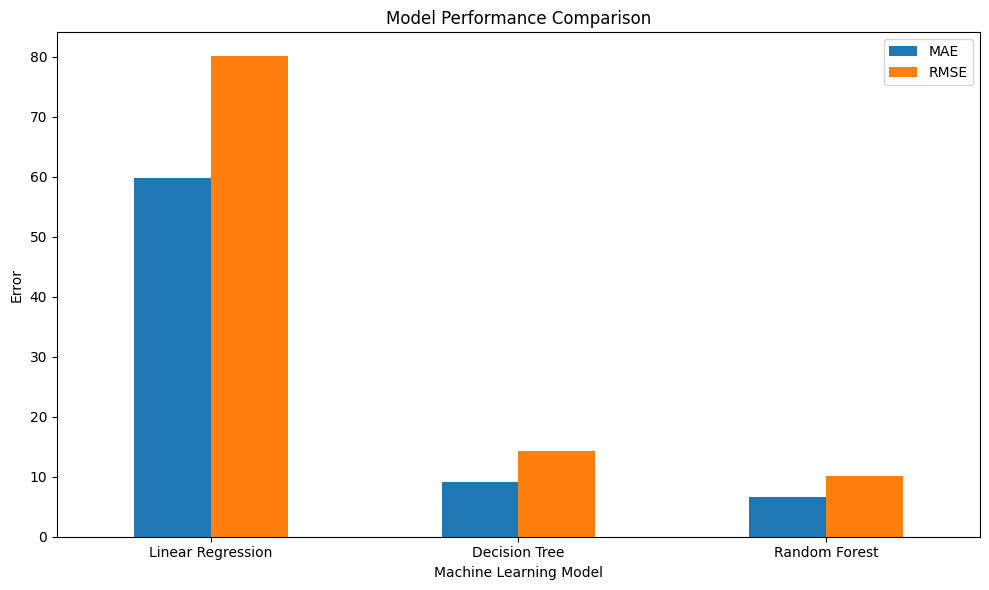

In [31]:
# Visualize model performance

results_df.set_index('Model')[['MAE', 'RMSE']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

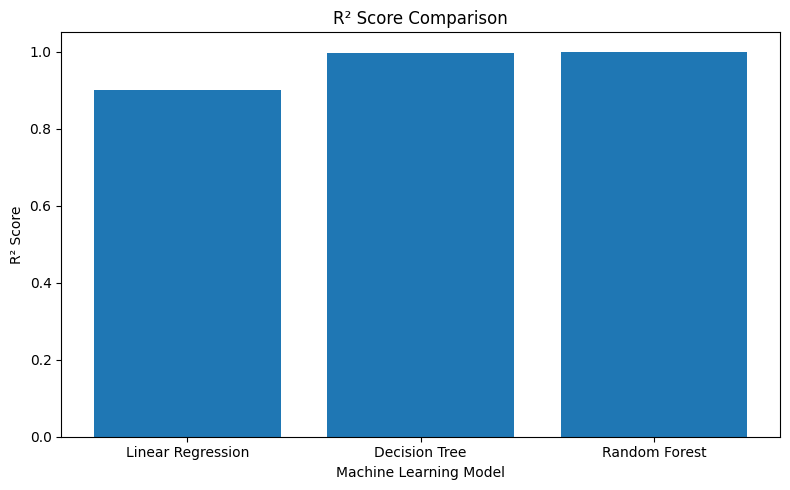

In [32]:
# Compare R² scores

plt.figure(figsize=(8, 5))

plt.bar(results_df['Model'], results_df['R² Score'])

plt.title('R² Score Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('R² Score')
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

**Feature Importance**

**Which factors are most important in predicting sales?**

Because Random Forest is our best model, we'll examine its feature importance.

In [33]:
# Get feature names after one-hot encoding

preprocessor_fitted = random_forest_model.named_steps['preprocessor']

feature_names = preprocessor_fitted.get_feature_names_out()

# Get feature importance from Random Forest
rf_model = random_forest_model.named_steps['model']

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display the top 15 features
feature_importance.head(15)

,Feature,Importance
27,numerical__Quantity,0.518532
26,numerical__Unit price,0.479153
28,numerical__Rating,0.000547
23,categorical__Day_of_Week_Thursday,0.000146
25,categorical__Day_of_Week_Wednesday,0.000089
12,categorical__Product line_Food and beverages,0.000089
15,categorical__Product line_Sports and travel,0.000084
16,categorical__Payment_Cash,0.000083
17,categorical__Payment_Credit card,0.000081
9,categorical__Gender_Male,0.000072


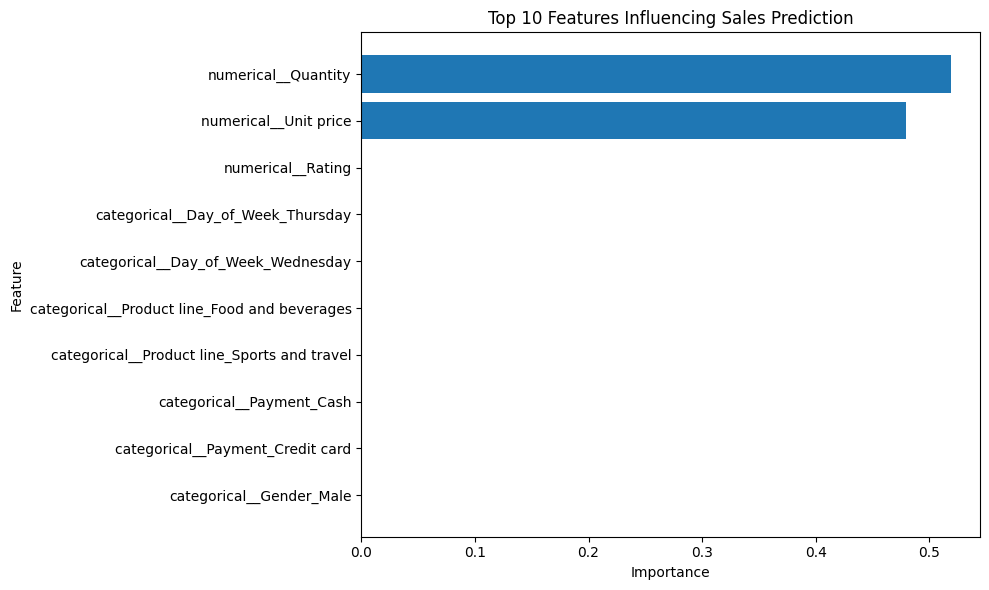

In [34]:
# Visualize top 10 important features

top_features = feature_importance.head(10).sort_values(
    by='Importance'
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 10 Features Influencing Sales Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

**Feature Importance Interpretation**

The feature importance analysis shows that Quantity and Unit price are the two most important predictors of sales. Quantity has the highest importance, followed by Unit price. This indicates that the number of items purchased and their prices are the main factors influencing the value of a transaction. Other factors, including rating, customer type, gender, payment method, product line, and day of the week, had much smaller contributions to the model's predictions.


In [35]:
# Compare actual and predicted sales

comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': forest_predictions
})

print(comparison.head(10))

   Actual Sales  Predicted Sales
0      523.9710       529.600050
1      616.9800       578.357430
2      408.7335       409.249785
3      135.3555       139.687275
4       45.9270        48.529215
5      618.9750       576.131115
6      127.8270       125.055630
7      731.6925       708.657600
8      450.1035       455.860650
9      138.1275       126.817950


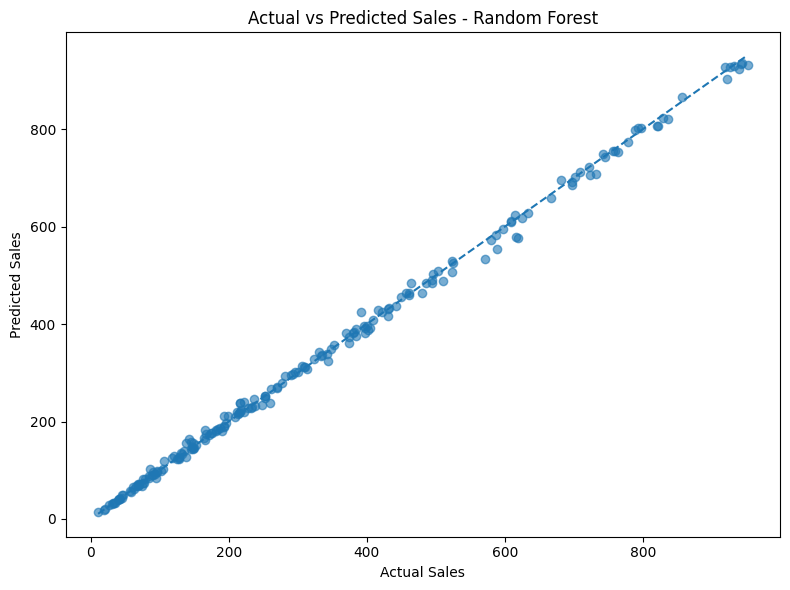

In [36]:
# Actual vs Predicted Sales

plt.figure(figsize=(8, 6))

plt.scatter(y_test, forest_predictions, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title('Actual vs Predicted Sales - Random Forest')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.tight_layout()
plt.show()

Actual vs Predicted Sales Interpretation
bold text
The Actual vs Predicted Sales plot shows that most of the predicted values are very close to the actual sales values. The points are concentrated around the diagonal line, indicating that the Random Forest model provides accurate predictions. This result is consistent with the model's high R² score of 0.9984 and low RMSE of 10.13.

**Business Insights**

1.Quantity is the
 strongest predictor of sales.The business should monitor purchasing quantities and stock levels carefully to ensure that popular products remain available.

2.Unit price is also a major factor affecting sales. Pricing decisions should consider both customer demand and the expected transaction value.

3.Food and beverages generated the highest total sales among the product lines. This category should receive appropriate inventory attention to reduce the risk of stock shortages.

4.Giza recorded the highest total sales among the three branches. Management can examine the practices and customer demand patterns at Giza to identify strategies that could be applied to the other branches.

5.Members generated substantially more sales than normal customers. The supermarket could strengthen its membership and loyalty programme to encourage repeat purchases.

6.Cash and E-wallet payments generated higher total sales than credit cards. The supermarket should continue supporting multiple payment options to provide customers with flexibility.

7.Sales generally increase as the quantity purchased increases. This relationship can help the supermarket plan inventory and anticipate the value of larger transactions.



## **Conclusion**

This project developed machine learning models to predict total sales per transaction using the supermarket sales dataset. The analysis identified important sales patterns across product lines, branches, customer types, genders, payment methods, and transaction quantities.

Three regression models were evaluated: Linear Regression, Decision Tree, and Random Forest. The Random Forest model performed best, achieving an MAE of 6.67, RMSE of 10.13, and R² score of 0.9984. The feature importance analysis showed that Quantity and Unit price were the main predictors of transaction sales.

The results demonstrate that machine learning can provide highly accurate transaction-level sales predictions and support better inventory planning, pricing decisions, staffing, and business strategy. However, because transaction sales are mathematically related to quantity and unit price in this dataset, the very high model performance should be interpreted with this limitation in mind.
